In [1]:
import torch

from Text_encoder import Text_encoder
from UNET import UNet
from DefussionBlock import SinusoidalTimeEmbedding, TimeEmbedding
from Upscalar.Upscaler import Upscaler
from Token.TTI_Tokenizer import TTITokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"

MAX_LENGTH = 64
TEXT_DIM = 512
TIME_DIM = 256
N_HEAD = 8
N_LAYERS = 6
DROPOUT = 0.1

tokenizer = TTITokenizer("Token/bpe_tokenizer.json", max_length=MAX_LENGTH)

text_encoder = Text_encoder(n_head=N_HEAD,n_layer=N_LAYERS,num_embeddings=tokenizer.vocab_size,embedding_dim=TEXT_DIM,max_length=MAX_LENGTH,dropout=DROPOUT).to(device)
unet = UNet(time_dim=TIME_DIM,text_dim=TEXT_DIM).to(device)

upscaler = Upscaler().to(device)

tti = torch.load("checkpoints/TTI.pt", map_location=device, weights_only=True)
unet.load_state_dict(tti["unet"])
text_encoder.load_state_dict(tti["text_encoder"])

up = torch.load("checkpoints/upscaler.pt", map_location=device, weights_only=True)
upscaler.load_state_dict(up["model_state_dict"])

text_encoder.eval()
unet.eval()
upscaler.eval()

time_embedding = SinusoidalTimeEmbedding(TIME_DIM).to(device)
time_encoder = TimeEmbedding(TIME_DIM, TIME_DIM).to(device)

In [ ]:
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display  # <-- was missing `display`

@torch.no_grad()
def generate_complete(prompt, tokenizer, text_encoder, unet, noise_scheduler, upscaler, device, image_size=64, save_every=25):

    text_encoder.eval()
    unet.eval()
    upscaler.eval()

    encoded = tokenizer.encode_ids(prompt)

    input_ids = torch.tensor([encoded["input_ids"]], dtype=torch.long, device=device)
    attention_mask = torch.tensor([encoded["attention_mask"]], dtype=torch.long, device=device)

    text_features = text_encoder(input_ids, attention_mask)

    x = torch.randn(1, 3, image_size, image_size, device=device)

    frames = []
    steps = []

    for i in reversed(range(noise_scheduler.timesteps)):
        t = torch.tensor([i], device=device)
        predicted_noise = unet(x, t, text_features)

        alpha_bar = noise_scheduler.alpha_cumprod[i].to(device)
        sqrt_alpha_bar = torch.sqrt(alpha_bar)
        sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

        x0_pred = (x - sqrt_one_minus_alpha_bar * predicted_noise) / sqrt_alpha_bar
        x0_pred = x0_pred.clamp(-1, 1)

        if i > 0:
            alpha_bar_prev = noise_scheduler.alpha_cumprod[i - 1].to(device)

            beta = noise_scheduler.betas[i].to(device)
            alpha = noise_scheduler.alphas[i].to(device)

            coef_x0 = (torch.sqrt(alpha_bar_prev) * beta / (1.0 - alpha_bar))
            coef_xt = (torch.sqrt(alpha) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar))

            mean = coef_x0 * x0_pred + coef_xt * x
            variance = (beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar))

            noise = torch.randn_like(x)
            x = mean + torch.sqrt(variance) * noise
        else:
            x = x0_pred

        if i % save_every == 0 or i == 0:
            frames.append(((x.clamp(-1, 1) + 1) / 2)[0].permute(1, 2, 0).cpu().numpy())
            steps.append(i)

    raw_64 = x.clamp(-1, 1)
    upscaled_256 = upscaler(raw_64).clamp(-1, 1)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(n):
        im.set_data(frames[n])
        ax.set_title(f"t = {steps[n]}")
        return [im]

    animation = FuncAnimation(fig, update, frames=len(frames), interval=120, blit=True)
    plt.close(fig)

    display(HTML(animation.to_jshtml()))

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(((raw_64[0] + 1) / 2).permute(1, 2, 0).cpu())
    ax[0].set_title("64×64")
    ax[0].axis("off")

    ax[1].imshow(((upscaled_256[0] + 1) / 2).permute(1, 2, 0).cpu())
    ax[1].set_title("256×256")
    ax[1].axis("off")

    plt.show()

    return raw_64, upscaled_256

In [3]:
from CosineNoiseScheduler import CosineNoiseScheduler
TIMESTEPS = 1000
noise_scheduler = CosineNoiseScheduler(timesteps=TIMESTEPS)

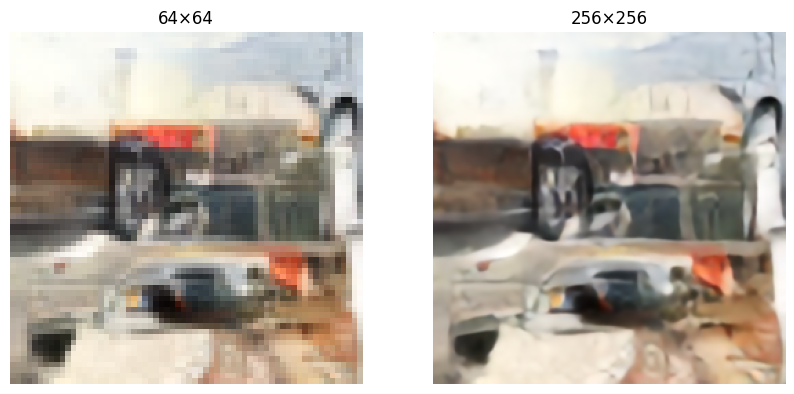

In [20]:
raw_64, upscaled_256 = generate_complete("a ",tokenizer, text_encoder, unet,noise_scheduler, upscaler, device)